In [4]:
!pip install ultralytics
!pip install paddleocr
!pip install paddlepaddle
!pip install opencv-python
!pip install pandas
!pip install scikit-learn

In [5]:
import cv2
import pandas as pd
from ultralytics import YOLO

print("Setup Successful!")

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\FATHIMS\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Setup Successful!


Image Shape: (3264, 2448, 3)


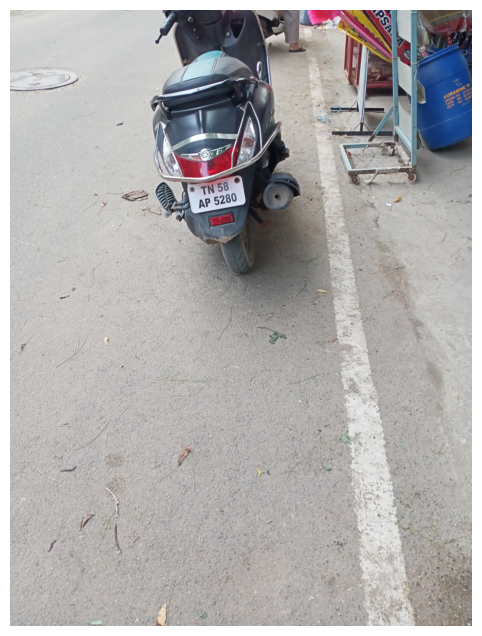

In [8]:
import cv2
import matplotlib.pyplot as plt

image_path = r"C:\Users\FATHIMS\Downloads\archive (1)\number_plate_images_ocr\number_plate_images_ocr\dc_license_plates_VYA8KOAVKLW6PJYK.jpg"

img = cv2.imread(image_path)

print("Image Shape:", img.shape)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,8))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

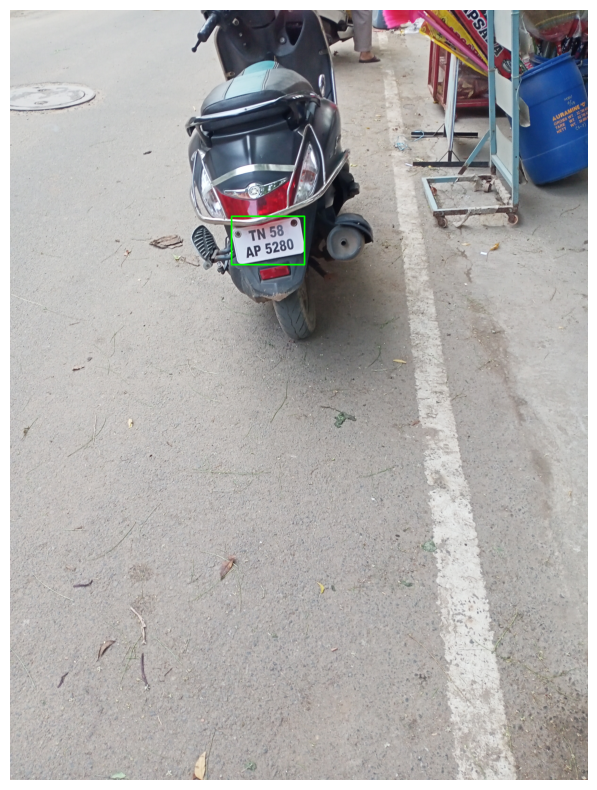

In [9]:
import cv2
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt

# Image Path
image_path = r"C:\Users\FATHIMS\Downloads\archive (1)\number_plate_images_ocr\number_plate_images_ocr\dc_license_plates_VYA8KOAVKLW6PJYK.jpg"

# XML Path
xml_path = r"C:\Users\FATHIMS\Downloads\archive (1)\number_plate_annos_ocr\number_plate_annos_ocr\dc_license_plates_VYA8KOAVKLW6PJYK.xml"

# Read image
img = cv2.imread(image_path)

# Parse XML
tree = ET.parse(xml_path)
root = tree.getroot()

# Loop through all number plates
for obj in root.findall("object"):

    bbox = obj.find("bndbox")

    xmin = int(float(bbox.find("xmin").text))
    ymin = int(float(bbox.find("ymin").text))
    xmax = int(float(bbox.find("xmax").text))
    ymax = int(float(bbox.find("ymax").text))

    # Draw rectangle
    cv2.rectangle(
        img,
        (xmin, ymin),
        (xmax, ymax),
        (0, 255, 0),
        5
    )

# Convert BGR → RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,10))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [10]:
import xml.etree.ElementTree as ET

xml_path = r"C:\Users\FATHIMS\Downloads\archive (1)\number_plate_annos_ocr\number_plate_annos_ocr\dc_license_plates_VYA8KOAVKLW6PJYK.xml"

tree = ET.parse(xml_path)
root = tree.getroot()

print("Detected Number Plates:\n")

for obj in root.findall("object"):

    attributes = obj.find("attributes")

    if attributes is not None:

        for attr in attributes.findall("attribute"):

            name = attr.find("name").text

            if name == "number_plate_text":
                plate_text = attr.find("value").text
                print(plate_text)

Detected Number Plates:

TN58AP5280


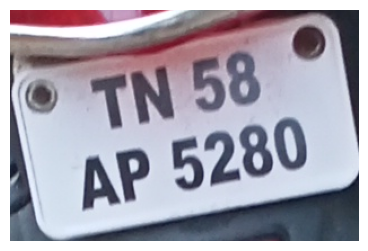

In [11]:
import cv2
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt

image_path = r"C:\Users\FATHIMS\Downloads\archive (1)\number_plate_images_ocr\number_plate_images_ocr\dc_license_plates_VYA8KOAVKLW6PJYK.jpg"

xml_path = r"C:\Users\FATHIMS\Downloads\archive (1)\number_plate_annos_ocr\number_plate_annos_ocr\dc_license_plates_VYA8KOAVKLW6PJYK.xml"

img = cv2.imread(image_path)

tree = ET.parse(xml_path)
root = tree.getroot()

for obj in root.findall("object"):

    bbox = obj.find("bndbox")

    xmin = int(float(bbox.find("xmin").text))
    ymin = int(float(bbox.find("ymin").text))
    xmax = int(float(bbox.find("xmax").text))
    ymax = int(float(bbox.find("ymax").text))

    plate = img[ymin:ymax, xmin:xmax]

    plate_rgb = cv2.cvtColor(plate, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8,3))
    plt.imshow(plate_rgb)
    plt.axis("off")
    plt.show()

In [12]:
import os
import xml.etree.ElementTree as ET

xml_folder = r"C:\Users\FATHIMS\Downloads\archive (1)\number_plate_annos_ocr\number_plate_annos_ocr"

yolo_folder = r"C:\Users\FATHIMS\Downloads\yolo_labels"

os.makedirs(yolo_folder, exist_ok=True)

for xml_file in os.listdir(xml_folder):

    if not xml_file.endswith(".xml"):
        continue

    xml_path = os.path.join(xml_folder, xml_file)

    tree = ET.parse(xml_path)
    root = tree.getroot()

    width = float(root.find("size/width").text)
    height = float(root.find("size/height").text)

    yolo_lines = []

    for obj in root.findall("object"):

        bbox = obj.find("bndbox")

        xmin = float(bbox.find("xmin").text)
        ymin = float(bbox.find("ymin").text)
        xmax = float(bbox.find("xmax").text)
        ymax = float(bbox.find("ymax").text)

        x_center = ((xmin + xmax) / 2) / width
        y_center = ((ymin + ymax) / 2) / height

        box_width = (xmax - xmin) / width
        box_height = (ymax - ymin) / height

        yolo_lines.append(
            f"0 {x_center} {y_center} {box_width} {box_height}"
        )

    txt_name = xml_file.replace(".xml", ".txt")
    txt_path = os.path.join(yolo_folder, txt_name)

    with open(txt_path, "w") as f:
        f.write("\n".join(yolo_lines))

print("Conversion Completed!")

Conversion Completed!


In [13]:
import os

label_folder = r"C:\Users\FATHIMS\Downloads\yolo_labels"

print("Number of label files:", len(os.listdir(label_folder)))

Number of label files: 20


In [14]:
import os

xml_folder = r"C:\Users\FATHIMS\Downloads\archive (1)\number_plate_annos_ocr\number_plate_annos_ocr"

xml_files = [f for f in os.listdir(xml_folder) if f.endswith(".xml")]

print("Number of XML files:", len(xml_files))

Number of XML files: 20


In [15]:
import os

image_folder = r"C:\Users\FATHIMS\Downloads\archive (1)\number_plate_images_ocr\number_plate_images_ocr"

images = [f for f in os.listdir(image_folder) if f.lower().endswith((".jpg", ".jpeg", ".png"))]

print("Number of images:", len(images))

Number of images: 20


In [16]:
import os
import random
import shutil

# Folders
image_folder = r"C:\Users\FATHIMS\Downloads\archive (1)\number_plate_images_ocr\number_plate_images_ocr"
label_folder = r"C:\Users\FATHIMS\Downloads\yolo_labels"

dataset_folder = r"C:\Users\FATHIMS\Downloads\numberplate_dataset"

# Create folders
for path in [
    "images/train",
    "images/val",
    "labels/train",
    "labels/val"
]:
    os.makedirs(os.path.join(dataset_folder, path), exist_ok=True)

# Get image files
images = [f for f in os.listdir(image_folder) if f.endswith(".jpg")]

random.shuffle(images)

split = int(len(images) * 0.8)

train_images = images[:split]
val_images = images[split:]

# Copy train files
for img in train_images:

    shutil.copy(
        os.path.join(image_folder, img),
        os.path.join(dataset_folder, "images/train", img)
    )

    label = img.replace(".jpg", ".txt")

    shutil.copy(
        os.path.join(label_folder, label),
        os.path.join(dataset_folder, "labels/train", label)
    )

# Copy validation files
for img in val_images:

    shutil.copy(
        os.path.join(image_folder, img),
        os.path.join(dataset_folder, "images/val", img)
    )

    label = img.replace(".jpg", ".txt")

    shutil.copy(
        os.path.join(label_folder, label),
        os.path.join(dataset_folder, "labels/val", label)
    )

print("Dataset Split Complete!")
print("Train:", len(train_images))
print("Validation:", len(val_images))

Dataset Split Complete!
Train: 16
Validation: 4


In [17]:
yaml_content = """
path: C:/Users/FATHIMS/Downloads/numberplate_dataset

train: images/train
val: images/val

names:
  0: number_plate
"""

with open("dataset.yaml", "w") as f:
    f.write(yaml_content)

print("dataset.yaml created successfully!")

dataset.yaml created successfully!


In [18]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="dataset.yaml",
    epochs=30,
    imgsz=640,
    batch=4
)

Ultralytics 8.4.60  Python-3.13.9 torch-2.12.0+cpu CPU (AMD Ryzen 7 5825U with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, persp

In [19]:
from ultralytics import YOLO

# Load trained model
model = YOLO(r"C:\Users\FATHIMS\runs\detect\train\weights\best.pt")

# Run detection
results = model.predict(
    source=r"C:\Users\FATHIMS\Downloads\archive (1)\input.mp4",
    conf=0.25,
    save=True
)

print("Video detection completed!")


WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/441) C:\Users\FATHIMS\Downloads\archive (1)\input.mp4: 640x288 1 number_plate, 72.6ms
video 1/1 (frame 2/441) C:\Users\FATHIMS\Downloads\archive (1)\input.mp4: 640x288 (no detections), 43.6ms
video 1/1 (frame 3/441) C:\Users\FATHIMS\Downloads\archive (1)\input.mp4: 640x288 (no detections), 56.6ms
video 1/1 (frame 4/441) C:\Users\FATHIMS\Downloads\archive (1)\input.mp4: 640x288 (no detections), 42.3ms
video 1/1 (frame 5/441) C:\Users\FATHI

In [20]:
import os

runs_folder = r"C:\Users\FATHIMS\runs\detect"

print(os.listdir(runs_folder))

['predict', 'train']


In [24]:
!pip install easyocr

  Using cached ninja-1.13.0-py3-none-win_amd64.whl.metadata (5.1 kB)
   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.9 MB 4.0 MB/s eta 0:00:01
   -------------- ------------------------- 1.0/2.9 MB 2.5 MB/s eta 0:00:01
   -------------- ------------------------- 1.0/2.9 MB 2.5 MB/s eta 0:00:01
   ------------------ --------------------- 1.3/2.9 MB 1.5 MB/s eta 0:00:02
   ------------------------- -------------- 1.8/2.9 MB 1.8 MB/s eta 0:00:01
   ----------------------------- ---------- 2.1/2.9 MB 1.8 MB/s eta 0:00:01
   ----------------------------- ---------- 2.1/2.9 MB 1.8 MB/s eta 0:00:01
   ------------------------------------ --- 2.6/2.9 MB

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\FATHIMS\\anaconda3\\Lib\\site-packages\\cv2\\cv2.pyd'
Consider using the `--user` option or check the permissions.



In [1]:
import easyocr

reader = easyocr.Reader(['en'])

result = reader.readtext(
    r"C:\Users\FATHIMS\Downloads\archive (1)\number_plate_images_ocr\number_plate_images_ocr\dc_license_plates_VYA8KOAVKLW6PJYK.jpg"
)

for item in result:
    print(item)

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

C:\Users\FATHIMS\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


([[np.int32(2412), np.int32(385)], [np.int32(2439), np.int32(385)], [np.int32(2439), np.int32(412)], [np.int32(2412), np.int32(412)]], 'P0', np.float64(0.15111518151709724))
([[np.int32(1005), np.int32(900)], [np.int32(1172), np.int32(900)], [np.int32(1172), np.int32(988)], [np.int32(1005), np.int32(988)]], 'TN 58', np.float64(0.9995731732548053))
([[np.int32(994), np.int32(989)], [np.int32(1070), np.int32(989)], [np.int32(1070), np.int32(1055)], [np.int32(994), np.int32(1055)]], 'AP', np.float64(0.9930399044342824))
([[np.float64(1910.154696648639), np.float64(-3.960215524426733)], [np.float64(1967.4937607344598), np.float64(-40.986445367168585)], [np.float64(2067.845303351361), np.float64(119.96021552442673)], [np.float64(2010.5062392655402), np.float64(158.98644536716859)]], '8', np.float64(0.6817680630108249))
([[np.float64(2339.1430466182296), np.float64(375.2572186472918)], [np.float64(2380.2133466387004), np.float64(353.4100975079098)], [np.float64(2390.8569533817704), np.float6

In [3]:
from ultralytics import YOLO
import easyocr
import cv2

# Load trained YOLO model
model = YOLO(r"C:\Users\FATHIMS\runs\detect\train\weights\best.pt")

# Initialize OCR
reader = easyocr.Reader(['en'])

# Input video
video_path = r"C:\Users\FATHIMS\Downloads\archive (1)\input.mp4"

# Open video
cap = cv2.VideoCapture(video_path)

# Get video properties
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

# Output video
output_path = r"C:\Users\FATHIMS\Downloads\output_anpr.mp4"

out = cv2.VideoWriter(
    output_path,
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps,
    (width, height)
)

frame_count = 0

while cap.isOpened():

    ret, frame = cap.read()

    if not ret:
        break

    frame_count += 1

    # YOLO Detection
    results = model(frame)

    for result in results:

        boxes = result.boxes

        for box in boxes:

            x1, y1, x2, y2 = map(int, box.xyxy[0])

            # Crop number plate
            plate = frame[y1:y2, x1:x2]

            if plate.size == 0:
                continue

            # OCR
            ocr_result = reader.readtext(plate)

            plate_text = ""

            for item in ocr_result:
                plate_text += item[1] + " "

            plate_text = plate_text.strip()

            # Draw bounding box
            cv2.rectangle(
                frame,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                2
            )

            # Draw detected text
            cv2.putText(
                frame,
                plate_text,
                (x1, max(y1 - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0, 255, 0),
                2
            )

    # Save frame
    out.write(frame)

    if frame_count % 30 == 0:
        print(f"Processed {frame_count} frames")

# Release resources
cap.release()
out.release()

print("\nProcessing completed successfully!")
print(f"Output video saved at:\n{output_path}")

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.



0: 640x288 1 number_plate, 61.1ms
Speed: 2.1ms preprocess, 61.1ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 288)

0: 640x288 (no detections), 48.3ms
Speed: 1.8ms preprocess, 48.3ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 288)

0: 640x288 (no detections), 48.4ms
Speed: 2.2ms preprocess, 48.4ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 288)

0: 640x288 (no detections), 52.5ms
Speed: 1.7ms preprocess, 52.5ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 288)

0: 640x288 (no detections), 48.8ms
Speed: 1.8ms preprocess, 48.8ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 288)

0: 640x288 (no detections), 45.0ms
Speed: 2.2ms preprocess, 45.0ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 288)

0: 640x288 (no detections), 47.4ms
Speed: 1.9ms preprocess, 47.4ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 288)

0: 640x288 (no detections), 46.7ms
Speed: 1.5ms preprocess, 46.7ms in

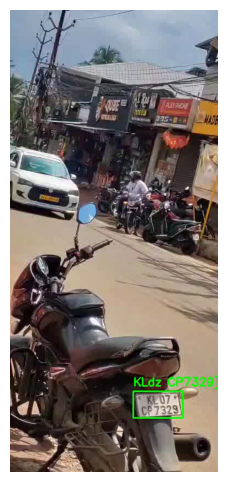

In [9]:
import cv2
import matplotlib.pyplot as plt

video_path = r"C:\Users\FATHIMS\Downloads\output_anpr.mp4"

cap = cv2.VideoCapture(video_path)

ret, frame = cap.read()

if ret:
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12,6))
    plt.imshow(frame)
    plt.axis("off")
    plt.show()

cap.release()